In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report




In [45]:
df = pd.read_csv('C:/Users/pinki/OneDrive/Desktop/Data_science(infosis)/datascience/data/Cardiovascular_Disease.csv')

In [46]:
# GENDER 
'''
-----------------
1->female
1->male

cholestrole
----------------------
1 -> good
2-> average
3 -> high

glucose
------------------
1 -> good
2->average
3-> high

smoke,alcohol,active
0 -> no 
1 -> yes
'''

'\n-----------------\n1->female\n1->male\n\ncholestrole\n----------------------\n1 -> good\n2-> average\n3 -> high\n\nglucose\n------------------\n1 -> good\n2->average\n3-> high\n\nsmoke,alcohol,active\n0 -> no \n1 -> yes\n'

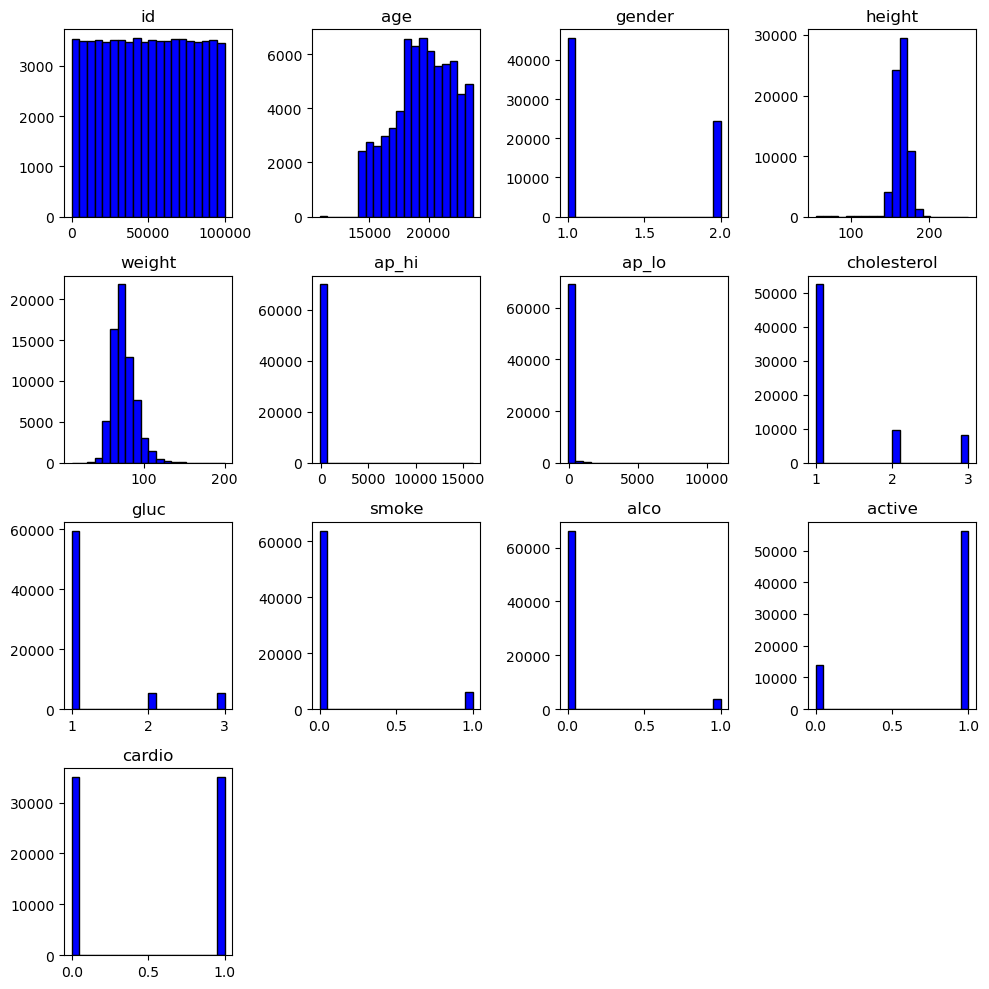

In [47]:
df.hist(figsize=(10, 10), bins=20, color='blue', edgecolor='black', linewidth=1.0, grid=False)
plt.tight_layout()
plt.show()


In [48]:
df['age'] = (df['age'] / 365).round()

### finding outliers in data set

(array([4.0000e+00, 0.0000e+00, 3.1090e+03, 4.0800e+03, 7.3030e+03,
        9.5200e+03, 1.4046e+04, 8.9810e+03, 1.3743e+04, 9.2140e+03]),
 array([30. , 33.5, 37. , 40.5, 44. , 47.5, 51. , 54.5, 58. , 61.5, 65. ]),
 <BarContainer object of 10 artists>)

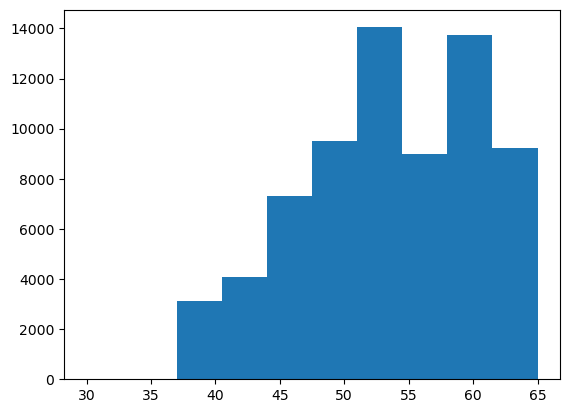

In [49]:
plt.hist(df['age'])

In [50]:
df['ap_hi'].min()

-150

In [51]:
df['age'].min()
df['age'].max()

65.0

# cleaning data from 

finding outliers
- systolic_pressure -->90 to 200
- diastolic_pressure -->40 to 90

In [52]:
df_sample = (df['ap_hi'].between(90,200)) & (df['ap_lo'].between(40,90))

In [53]:
df = df[df_sample]


In [54]:
df_sample = (df['ap_hi'].between(90, 220)) & (df['ap_lo'].between(40, 90))


In [55]:
df = df.loc[df_sample].copy()

In [56]:
df['weight'].min()

11.0

In [57]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.0,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.0,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52.0,1,165,64.0,130,70,3,1,0,0,0,1
4,4,48.0,1,156,56.0,100,60,1,1,0,0,0,0
5,8,60.0,1,151,67.0,120,80,2,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53.0,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62.0,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52.0,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61.0,1,163,72.0,135,80,1,2,0,0,0,1


In [58]:
weight_data = (df['weight']>=40) & (df['weight']<=140)

In [59]:
df= df[weight_data]

In [60]:
heighter = df['height']>= 120
df = df[heighter]

In [61]:
df['height'].max()

207

In [62]:
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [63]:
X= df[features]
Y =df[target]

In [64]:
# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [65]:
# Scale the feature values
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)



In [66]:
model = LogisticRegression(
    solver='lbfgs',
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scale, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [84]:
y_pred = model.predict(X_test_scale)

In [85]:
y_pred

array([0, 1, 0, ..., 0, 1, 0], shape=(12678,))

<mark>Purpose of calculating:<mark>

- Precision: How many predicted positives are actually correct.
- Recall: How many actual positives were correctly found.
- F1-score: A single score that balances precision and recall.
- Use: To measure how well a classification model performs.

# Metrics


In [82]:
cr = classification_report(Y_test, y_pred)
cm = confusion_matrix(Y_test, y_pred)   


# macro_avg
# class1+class2/number of class
# (0.77+0.66)/2
# weight avg


In [87]:
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       0.73      0.76      0.74      6746
           1       0.71      0.68      0.70      5932

    accuracy                           0.72     12678
   macro avg       0.72      0.72      0.72     12678
weighted avg       0.72      0.72      0.72     12678

[[5095 1651]
 [1893 4039]]


macro avg 
---------------------------------------------
class1 +class2 /2
(0.76 +0.67)/2
---------------------------------
weighted average 
((precision *support) +(class2 *support ))/total_number
((0.73*6759)+(0.72*5951))

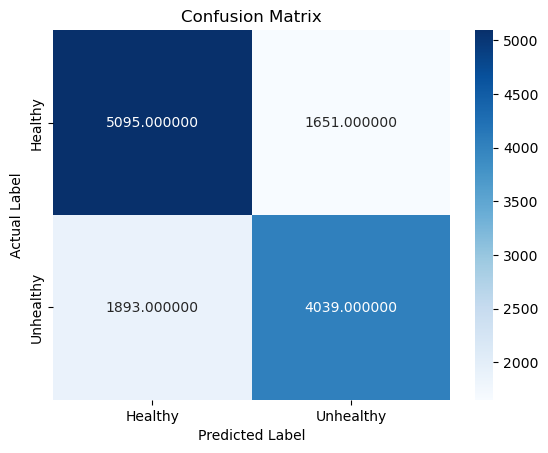

In [72]:
import seaborn as sns
sns.heatmap(
    cm,
    annot=True,
    fmt='0f',
    cmap='Blues',
    xticklabels=['Healthy', 'Unhealthy'],
    yticklabels=['Healthy', 'Unhealthy']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [88]:
input_data = {

    'age': [40, 30, 25, 50], 

    'gender': [1, 2, 2, 1], 

    'height': [150, 135, 168, 155], 

    'weight': [60, 50, 80, 55], 

    'ap_hi': [150, 130, 120, 140], 

    'ap_lo': [80, 80, 80, 80], 

    'cholesterol': [3, 2, 2, 1], 

    'gluc': [3, 2, 2, 1], 

    'smoke': [1, 1, 0, 0], 

    'alco': [0, 1, 0, 1], 

    'active': [0, 1, 1, 0]

}
x_new = pd.DataFrame(input_data)

In [75]:
x_new_scale =scaler.transform(x_new)

In [76]:
y_new_pred = model.predict(x_new_scale)
y_new_pred

array([1, 0, 0, 1])

In [77]:
x_new['predicted_cardio']= y_new_pred

In [78]:
pc= {
    0:'healthy',
    1:'unhealthy'
}
x_new['predicted_cardio']=x_new['predicted_cardio'].map(pc)

In [79]:
x_new

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,predicted_cardio
0,40,1,150,60,150,80,3,3,1,0,0,unhealthy
1,30,2,135,50,130,80,2,2,1,1,1,healthy
2,25,2,168,80,120,80,2,2,0,0,1,healthy
3,50,1,155,55,140,80,1,1,0,1,0,unhealthy
